In [17]:
# basic
import os
import pickle
import warnings
import numpy as np
import pandas as pd
from tqdm import tqdm
# pre processing
from sklearn import preprocessing as pre
# NN
import torch
import torch.nn as nn
from torch import Tensor
import torch.nn.functional as F
import torch.optim as optim
from torch.nn import MSELoss
from torch_geometric.nn import GCNConv
# val and plot
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import mean_absolute_error
from loguru import logger as log
#from ..val import calculate_metrics
# plot
import matplotlib.pyplot as plt
# foundation model
from functools import reduce

In [18]:
import itertools
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [19]:
import pmdarima as pm

In [20]:
plt.style.use("seaborn-v0_8-whitegrid")

In [21]:
SEED = 1345
def seed_everything(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
seed_everything(SEED)
#plt.style.use('seaborn-whitegrid')
#pd.set_option('display.float_format', '{:.16f}'.format)
warnings.filterwarnings('ignore')

## Data

In [22]:
sb = pd.read_parquet("/home/marcos/loader_03-04_2024.parquet")
sb.head()

,125960550,230565994,258781031,43768720,44072192,44783654,44783914,44784438,45833547,47568123
2024-03-01 05:00:00,1.333333,0.000000,70.792221,41.188599,1.724359,14.955100,2.032506,3.571820,5.877792,7.546274
2024-03-01 05:30:00,3.595238,1.583333,229.051071,172.071198,8.282966,44.559937,11.048912,18.211931,18.912033,18.276293
2024-03-01 06:00:00,4.812975,3.268518,424.853729,433.062469,18.825665,97.263435,26.276600,41.471294,40.731876,37.141144
2024-03-01 06:30:00,9.215629,5.256614,630.444153,743.177368,25.593414,149.329544,49.763138,71.520836,57.200085,53.487366
2024-03-01 07:00:00,12.585028,6.152447,841.874512,1132.739502,44.350349,204.275940,78.721497,107.241295,77.808769,75.446609


In [57]:
sb.columns

Index(['125960550', '230565994', '258781031', '43768720', '44072192',
       '44783654', '44783914', '44784438', '45833547', '47568123'],
      dtype='object')

In [23]:
# define X and Y
sbx = sb.query("index <= '2024-03-31 23:59:59'")
sbx.shape, sb.shape

((1238, 10), (3640, 10))

In [24]:
# define X and Y
sby = sb.query("index > '2024-03-31 23:59:59'")
sby.shape, sb.shape

((2402, 10), (3640, 10))

In [25]:
pred_len = abs(sbx.shape[0] - sb.shape[0])
pred_len

2402

In [32]:
sby.shape

(2402, 10)

In [26]:
## Grid Search

In [55]:
node = ["125960550"]
serie = sbx[node]

In [28]:
# Auto ARIMA com busca de parâmetros, incluindo sazonalidade
modelo_auto = pm.auto_arima(
    serie,
    start_p=0, max_p=3,
    start_q=0, max_q=3,
    d=None,            # auto determina o melhor d
    seasonal=True,
    start_P=0, max_P=2,
    start_Q=0, max_Q=2,
    D=None,            # auto determina o melhor D
    m=24,              # frequência sazonal, ex: 24 para dados horários
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    stepwise=True      # mais rápido
)

print("Resultados pos grid search")
print(modelo_auto.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=8008.676, Time=0.05 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=4499.395, Time=1.03 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=6548.585, Time=0.84 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=10015.926, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=4499.158, Time=0.07 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=4498.710, Time=1.02 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=4501.611, Time=2.07 sec
 ARIMA(1,0,0)(0,0,2)[24] intercept   : AIC=4476.307, Time=3.26 sec
 ARIMA(1,0,0)(1,0,2)[24] intercept   : AIC=4478.057, Time=8.27 sec
 ARIMA(0,0,0)(0,0,2)[24] intercept   : AIC=7976.507, Time=3.06 sec
 ARIMA(2,0,0)(0,0,2)[24] intercept   : AIC=4352.438, Time=3.68 sec
 ARIMA(2,0,0)(0,0,1)[24] intercept   : AIC=4351.615, Time=1.17 sec
 ARIMA(2,0,0)(0,0,0)[24] intercept   : AIC=4360.555, Time=0.09 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   : AIC=inf, Time=3.21 sec
 ARIMA(2,0,0)(1,0,0)[24

In [29]:
modelo_auto

ARIMA(order=(2, 0, 3), scoring_args={}, seasonal_order=(0, 0, 1, 24),
      suppress_warnings=True)

In [30]:
modelo_auto.order

(2, 0, 3)

In [31]:
modelo_auto.seasonal_order

(0, 0, 1, 24)

In [78]:
modelo = SARIMAX(serie,
                 order=modelo_auto.order,
                 seasonal_order=(1, 1, 1, 40),
                 enforce_stationarity=False,
                 enforce_invertibility=False)

resultado = modelo.fit()

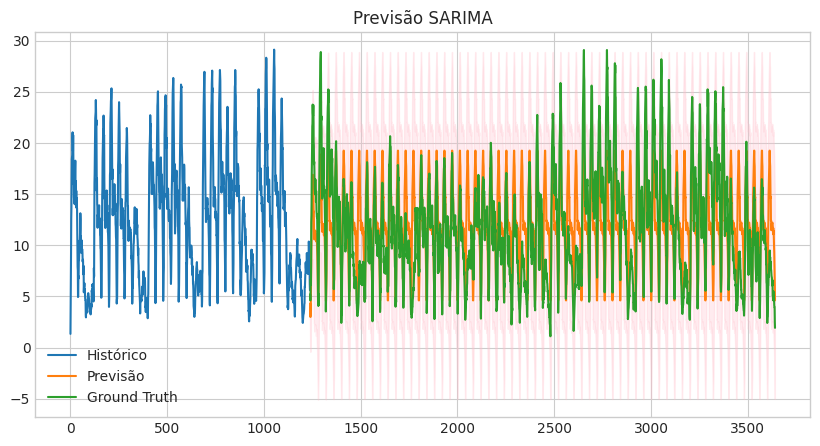

In [79]:
forecast = resultado.get_forecast(steps=pred_len)

# Média das previsões
media_prevista = forecast.predicted_mean

# Intervalo de confiança
ic = forecast.conf_int()

plt.figure(figsize=(10,5))
plt.plot(np.arange(1, sbx.shape[0]+1), serie, label='Histórico')
plt.plot(np.arange(sbx.shape[0]+1, (sbx.shape[0]+1) + sby.shape[0]), media_prevista, label='Previsão')
plt.plot(np.arange(sbx.shape[0]+1, (sbx.shape[0]+1) + sby.shape[0]), sby["125960550"].values, label='Ground Truth')
plt.fill_between(ic.index, ic.iloc[:, 0], ic.iloc[:, 1], color='pink', alpha=0.3)
plt.legend()
plt.title('Previsão SARIMA')
plt.show()

In [80]:
forecast.summary_frame()

125960550,mean,mean_se,mean_ci_lower,mean_ci_upper
1238,4.294228,0.975459,2.382363,6.206093
1239,2.987292,1.364532,0.312859,5.661725
1240,2.987155,1.735463,-0.414291,6.388601
1241,4.263293,2.124202,0.099933,8.426653
1242,5.069544,2.483247,0.202469,9.936619
...,...,...,...,...
3635,9.295710,4.915993,-0.339460,18.930879
3636,8.310684,4.915878,-1.324261,17.945628
3637,7.347786,4.915763,-2.286932,16.982504
3638,6.039335,4.915835,-3.595525,15.674195


In [67]:
y_true = sby[node].values
y_pred = media_prevista

In [68]:
mean_squared_error(y_true, y_pred)
mean_absolute_error(y_true, y_pred)

11.592199649892407

In [61]:
df_scores = pd.read_parquet("SARIMA-long-time.parquet")
df_scores

,node,mae,mse,r2,mape,model
0,125960550,11.643635,164.733244,-4.604544,0.995179,SARIMA
